<h1>Descriptive Statistics Tasks</h1> 
https://www.kaggle.com/datasets/faresashraf1001/supermarket-sales 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("faresashraf1001/supermarket-sales")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\stasy\.cache\kagglehub\datasets\faresashraf1001\supermarket-sales\versions\2


In [3]:
statistics = pd.read_csv("files/SuperMarket Analysis.csv")

In [4]:
statistics.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Sales,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [15]:
statistics.columns


Index(['Invoice ID', 'Branch', 'City', 'Customer type', 'Gender',
       'Product line', 'Unit price', 'Quantity', 'Tax 5%', 'Sales', 'Date',
       'Time', 'Payment', 'cogs', 'gross margin percentage', 'gross income',
       'Rating'],
      dtype='str')

1. Koks yra pardavimų (total) vidurkis ir mediana? 

In [16]:
mean_total = statistics["Sales"].mean()
median_total = statistics["Sales"].median()

print("Vidurkis:", mean_total)
print("Mediana:", median_total)


Vidurkis: 322.966749
Mediana: 253.848


2. Kuris padalinys (branch) turi didžiausius vidutinius pardavimus? Parodyti grafiškai 

Branch
Alex     312.354031
Cairo    319.872506
Giza     337.099715
Name: Sales, dtype: float64


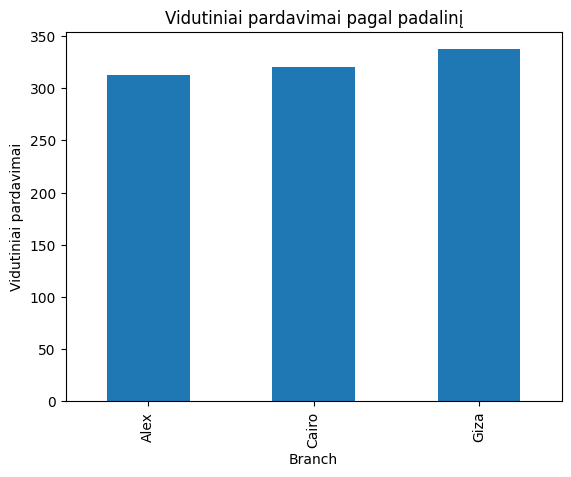

In [17]:
branch_avg = statistics.groupby("Branch")["Sales"].mean()

print(branch_avg)

# Grafikas
branch_avg.plot(kind="bar")
plt.title("Vidutiniai pardavimai pagal padalinį")
plt.ylabel("Vidutiniai pardavimai")
plt.show()


3. Kokie yra diapazonai ir IQR vieneto kainos(unit price)? 

In [8]:
unit_price_range = statistics["Unit price"].max() - statistics["Unit price"].min()
print("Diapazonas:", unit_price_range)


Diapazonas: 89.88


In [10]:
Q1 = statistics["Unit price"].quantile(0.25)
Q3 = statistics["Unit price"].quantile(0.75)
IQR = Q3 - Q1

print("IQR:", IQR)


IQR: 45.06


4. Patikrinti ar yra nuokrypių duomenyse. Pavaizduoti pardavimų nuokrypius su 
boxplot. 

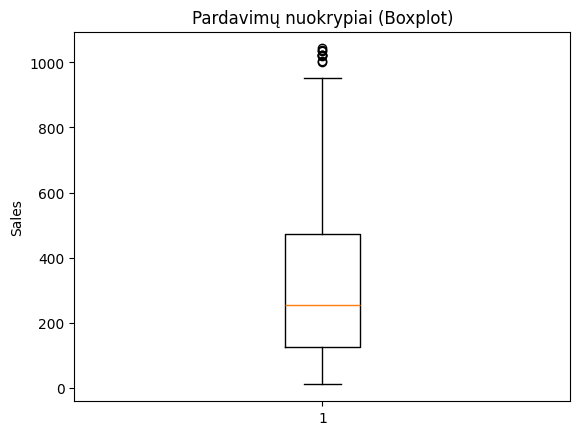

In [18]:
plt.boxplot(statistics["Sales"])
plt.title("Pardavimų nuokrypiai (Boxplot)")
plt.ylabel("Sales")
plt.show()


In [19]:
Q1 = statistics["Sales"].quantile(0.25)
Q3 = statistics["Sales"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = statistics[(statistics["Sales"] < lower_bound) | 
                      (statistics["Sales"] > upper_bound)]

print("Outlierių kiekis:", len(outliers))


Outlierių kiekis: 9


5. Koks dažniausiai naudojamas atsiskaitymo būdas(payment)? 

In [20]:
most_common_payment = statistics["Payment"].mode()[0]
print("Dažniausias atsiskaitymo būdas:", most_common_payment)


Dažniausias atsiskaitymo būdas: Ewallet


In [21]:
statistics["Payment"].value_counts()


Payment
Ewallet        345
Cash           344
Credit card    311
Name: count, dtype: int64

6. Kokie vidutiniai pardavimai pagal kategorijas(Product line)? 

Product line
Electronic accessories    319.632538
Fashion accessories       305.089298
Food and beverages        322.671517
Health and beauty         323.643020
Home and lifestyle        336.636956
Sports and travel         332.065220
Name: Sales, dtype: float64


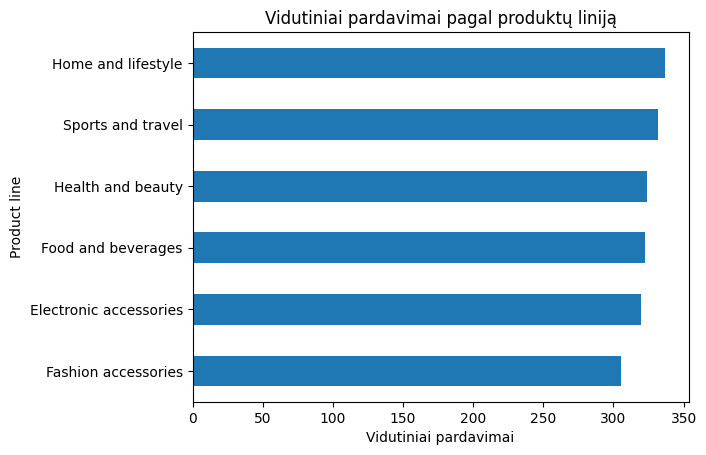

In [22]:
product_avg = statistics.groupby("Product line")["Sales"].mean()

print(product_avg)

product_avg.sort_values().plot(kind="barh")
plt.title("Vidutiniai pardavimai pagal produktų liniją")
plt.xlabel("Vidutiniai pardavimai")
plt.show()


7. Kurio tipo klientų pardavimų mediana yra didesnė? (customer type) 

In [23]:
customer_median = statistics.groupby("Customer type")["Sales"].median()

print(customer_median)


Customer type
Member    271.950
Normal    225.792
Name: Sales, dtype: float64
